# Real Estate EDA and Model Comparison

This notebook focuses on three things:
1. understanding feature distributions and skew
2. spotting outliers and the capped target
3. comparing Linear Regression, Random Forest, and XGBoost

In [5]:
import os
import sys
from pathlib import Path

sys.path.append(os.path.abspath('..'))

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor

from src.training.evaluate import evaluate_regression_model

In [6]:
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

In [7]:
feature_path = Path('../data/processed/california_housing_features.csv')
feature_df = pd.read_csv(feature_path)
feature_df.head()

,median_income,house_age,average_rooms,average_bedrooms,population,average_occupancy,latitude,longitude,median_house_value,bedroom_ratio,rooms_per_person
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526,0.146591,2.732919
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585,0.155797,2.956685
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521,0.129516,2.957661
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413,0.184458,2.283154
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422,0.172096,2.879646


## Basic summary

In [8]:
feature_df.describe().T

,count,mean,std,min,25%,50%,75%,max
median_income,20640.0,3.870671,1.899822,0.499900,2.563400,3.534800,4.743250,15.000100
house_age,20640.0,28.639486,12.585558,1.000000,18.000000,29.000000,37.000000,52.000000
average_rooms,20640.0,5.429000,2.474173,0.846154,4.440716,5.229129,6.052381,141.909091
average_bedrooms,20640.0,1.096675,0.473911,0.333333,1.006079,1.048780,1.099526,34.066667
population,20640.0,1425.476744,1132.462122,3.000000,787.000000,1166.000000,1725.000000,35682.000000
average_occupancy,20640.0,3.070655,10.386050,0.692308,2.429741,2.818116,3.282261,1243.333333
latitude,20640.0,35.631861,2.135952,32.540000,33.930000,34.260000,37.710000,41.950000
longitude,20640.0,-119.569704,2.003532,-124.350000,-121.800000,-118.490000,-118.010000,-114.310000
median_house_value,20640.0,2.068558,1.153956,0.149990,1.196000,1.797000,2.647250,5.000010
bedroom_ratio,20640.0,0.213075,0.058023,0.100000,0.175426,0.203181,0.239834,1.000000


In [9]:
feature_df.isna().sum().sort_values(ascending=False)

median_income         0
house_age             0
average_rooms         0
average_bedrooms      0
population            0
average_occupancy     0
latitude              0
longitude             0
median_house_value    0
bedroom_ratio         0
rooms_per_person      0
dtype: int64

## Skew check

High positive skew usually means a long right tail and potential outliers.

In [10]:
feature_df.skew(numeric_only=True).sort_values(ascending=False).to_frame('skew')

,skew
average_occupancy,97.639561
average_bedrooms,31.316956
average_rooms,20.697869
rooms_per_person,17.775133
population,4.935858
bedroom_ratio,2.246891
median_income,1.646657
median_house_value,0.977763
latitude,0.465953
house_age,0.060331


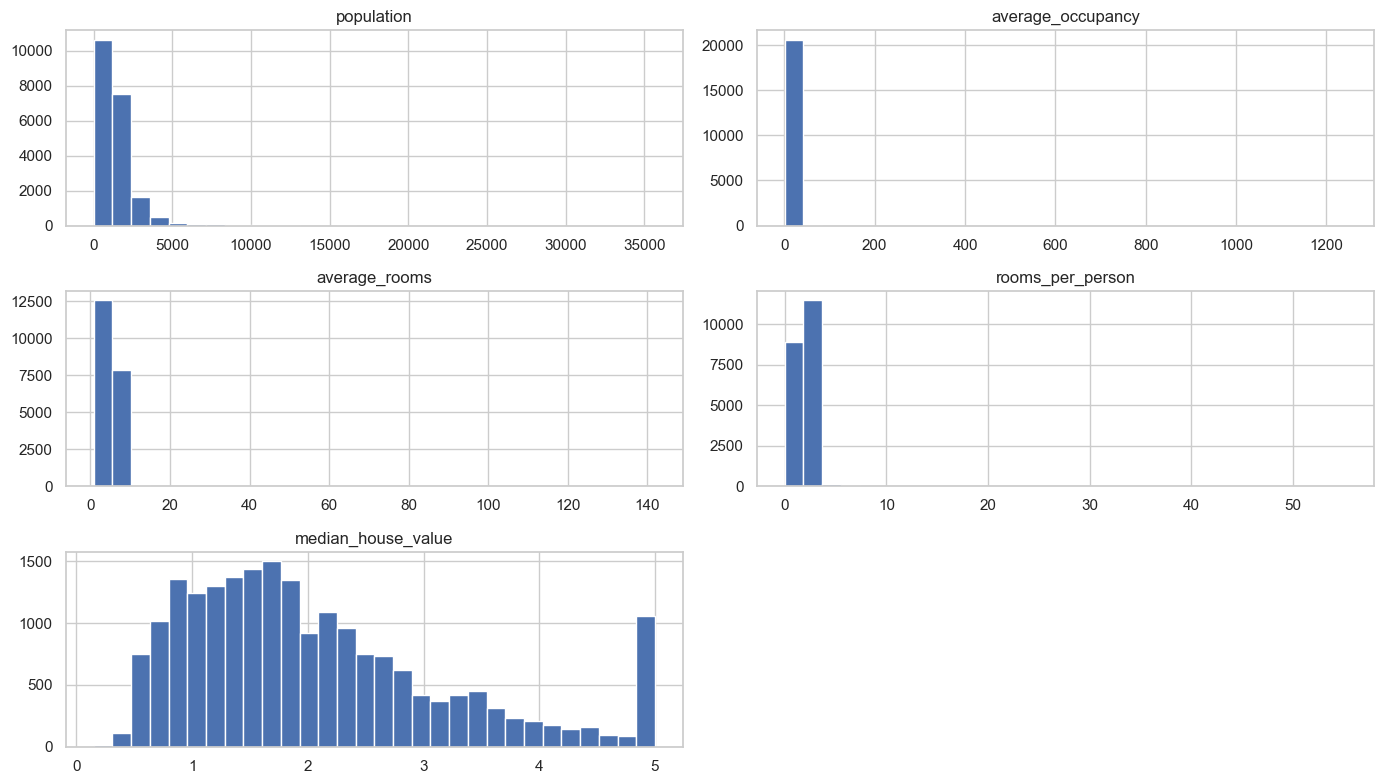

In [11]:
columns_to_plot = [
    'population',
    'average_occupancy',
    'average_rooms',
    'rooms_per_person',
    'median_house_value',
]

feature_df[columns_to_plot].hist(bins=30, figsize=(14, 8))
plt.tight_layout()

## Outlier inspection

In [12]:
for column in ['population', 'average_occupancy', 'average_rooms', 'rooms_per_person']:
    q1 = feature_df[column].quantile(0.25)
    q3 = feature_df[column].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    outlier_ratio = ((feature_df[column] < lower_bound) | (feature_df[column] > upper_bound)).mean()
    print(column, round(outlier_ratio, 4))

population 0.0579
average_occupancy 0.0344
average_rooms 0.0248
rooms_per_person 0.0195


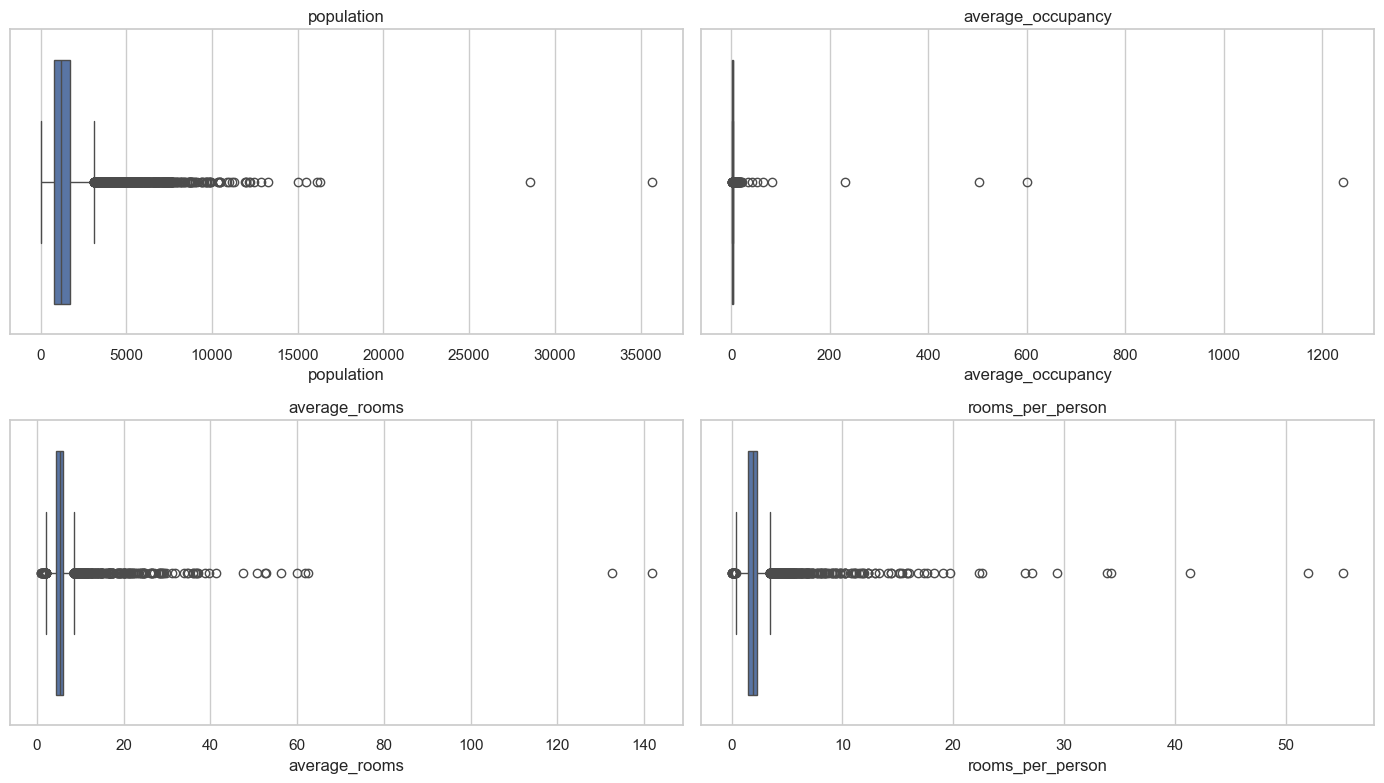

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
plot_columns = ['population', 'average_occupancy', 'average_rooms', 'rooms_per_person']
for axis, column in zip(axes.flatten(), plot_columns):
    sns.boxplot(x=feature_df[column], ax=axis)
    axis.set_title(column)
plt.tight_layout()

## Target cap check

This California housing target is known to be capped near 5.0.

In [14]:
feature_df['median_house_value'].max(), (feature_df['median_house_value'] >= 5.0).mean()

(np.float64(5.00001), np.float64(0.04806201550387597))

## Correlation view

In [15]:
corr = feature_df.corr(numeric_only=True)
corr['median_house_value'].sort_values(ascending=False).to_frame('target_correlation')

,target_correlation
median_house_value,1.000000
median_income,0.688075
rooms_per_person,0.209482
average_rooms,0.151948
house_age,0.105623
average_occupancy,-0.023737
population,-0.024650
longitude,-0.045967
average_bedrooms,-0.046701
latitude,-0.144160


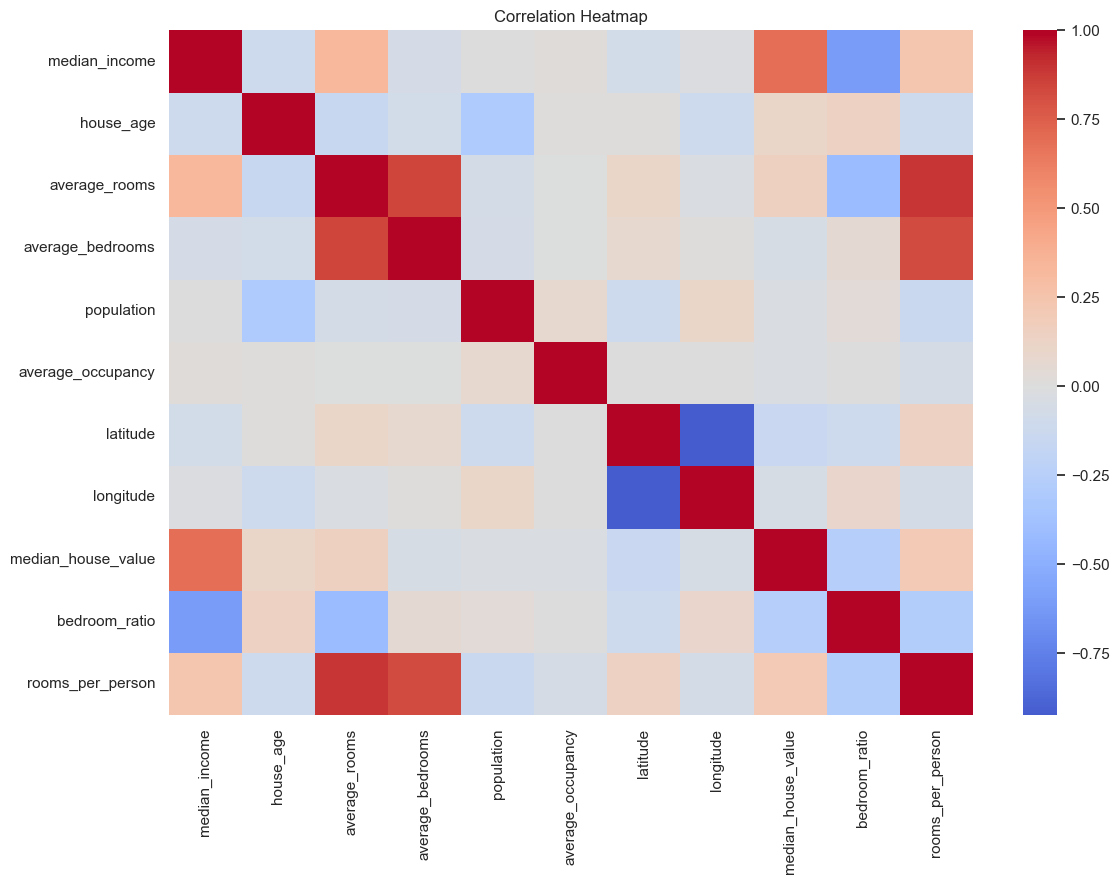

In [16]:
plt.figure(figsize=(12, 9))
sns.heatmap(corr, cmap='coolwarm', center=0)
plt.title('Correlation Heatmap')
plt.tight_layout()

## Feature vs target relationships

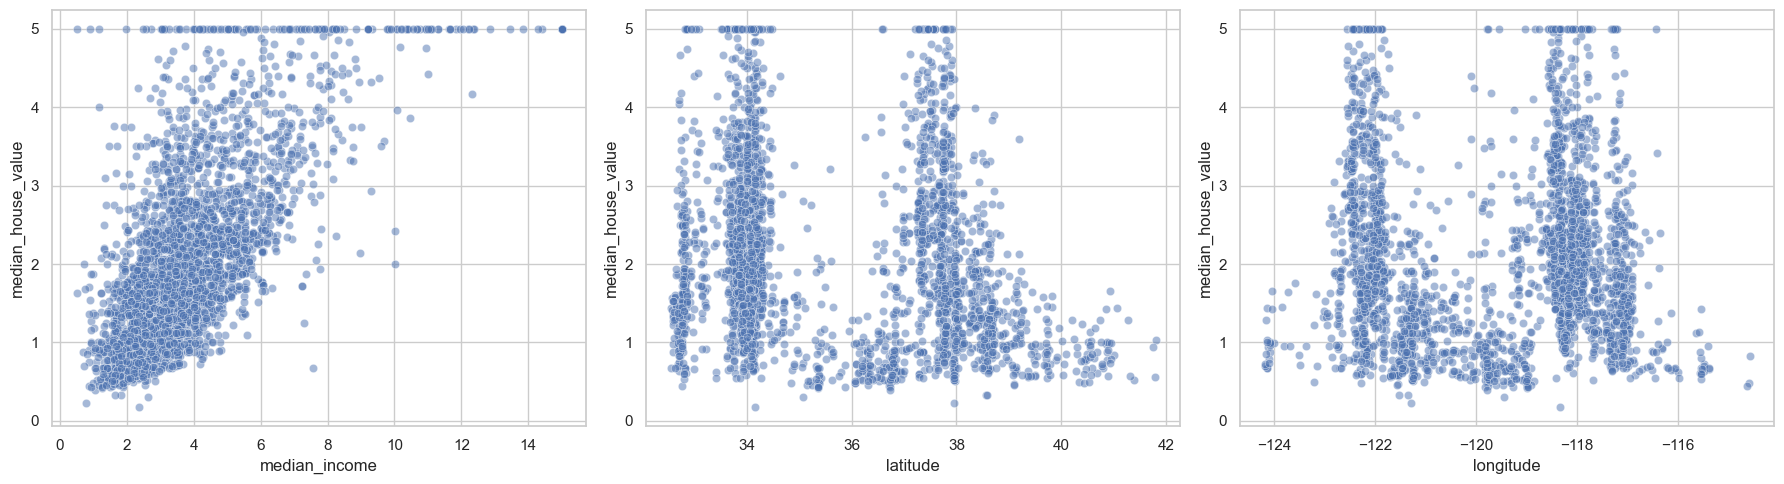

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.scatterplot(data=feature_df.sample(min(len(feature_df), 3000), random_state=42), x='median_income', y='median_house_value', ax=axes[0], alpha=0.5)
sns.scatterplot(data=feature_df.sample(min(len(feature_df), 3000), random_state=42), x='latitude', y='median_house_value', ax=axes[1], alpha=0.5)
sns.scatterplot(data=feature_df.sample(min(len(feature_df), 3000), random_state=42), x='longitude', y='median_house_value', ax=axes[2], alpha=0.5)
plt.tight_layout()

## Model comparison

In [18]:
X = feature_df.drop(columns=['median_house_value'])
y = feature_df['median_house_value']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
)

print(X_train.shape, X_test.shape)

(16512, 10) (4128, 10)


In [19]:
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)
linear_metrics = evaluate_regression_model(y_test, linear_model.predict(X_test))
linear_metrics

{'rmse': 0.6753472424631182,
 'mae': 0.4861644025414969,
 'r2': 0.6519453808117213}

In [20]:
rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=16,
    min_samples_split=4,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1,
)
rf_model.fit(X_train, y_train)
rf_metrics = evaluate_regression_model(y_test, rf_model.predict(X_test))
rf_metrics

{'rmse': 0.5059144093815288,
 'mae': 0.3295448801950746,
 'r2': 0.8046797649666222}

In [21]:
xgb_model = XGBRegressor(
    n_estimators=400,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.9,
    colsample_bytree=0.9,
    reg_alpha=0.0,
    reg_lambda=1.0,
    objective='reg:squarederror',
    random_state=42,
    n_jobs=-1,
)
xgb_model.fit(X_train, y_train)
xgb_metrics = evaluate_regression_model(y_test, xgb_model.predict(X_test))
xgb_metrics

{'rmse': 0.4457232829514774,
 'mae': 0.29305144212246864,
 'r2': 0.8483914195767054}

In [22]:
comparison_df = pd.DataFrame(
    {
        'linear_regression': linear_metrics,
        'random_forest': rf_metrics,
        'xgboost': xgb_metrics,
    }
)
comparison_df

,linear_regression,random_forest,xgboost
rmse,0.675347,0.505914,0.445723
mae,0.486164,0.329545,0.293051
r2,0.651945,0.804680,0.848391
